In [3]:
import warnings
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', size=14)
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.naive_bayes import GaussianNB

In [4]:
data = pd.read_csv('default.csv')

In [5]:
df = data.copy()

In [6]:
data.head()

,Gender,Loan.Offered,Job,Work.Exp,Credit.Score,EMI.Ratio,Status,Credit.History,Own house,Purpose,Dependents
0,Male,0,unskilled,14,86,3.0,No,poor,1,personal,2
1,Female,1,skilled,15,94,3.0,No,poor,1,personal,3
2,Male,0,unskilled,16,86,3.0,No,poor,1,personal,2
3,Female,1,skilled,13,94,3.0,No,poor,1,personal,3
4,Male,1,skilled,12,85,3.3,No,poor,1,personal,2


In [7]:
data.isnull().sum()

Gender            0
Loan.Offered      0
Job               0
Work.Exp          0
Credit.Score      0
EMI.Ratio         0
Status            0
Credit.History    0
Own house         0
Purpose           0
Dependents        0
dtype: int64

In [8]:
data.isna().sum()

Gender            0
Loan.Offered      0
Job               0
Work.Exp          0
Credit.Score      0
EMI.Ratio         0
Status            0
Credit.History    0
Own house         0
Purpose           0
Dependents        0
dtype: int64

In [9]:
data.isin([0]).sum()

Gender              0
Loan.Offered      190
Job                 0
Work.Exp            2
Credit.Score        0
EMI.Ratio           0
Status              0
Credit.History      0
Own house         181
Purpose             0
Dependents        103
dtype: int64

### Bivariate analysis

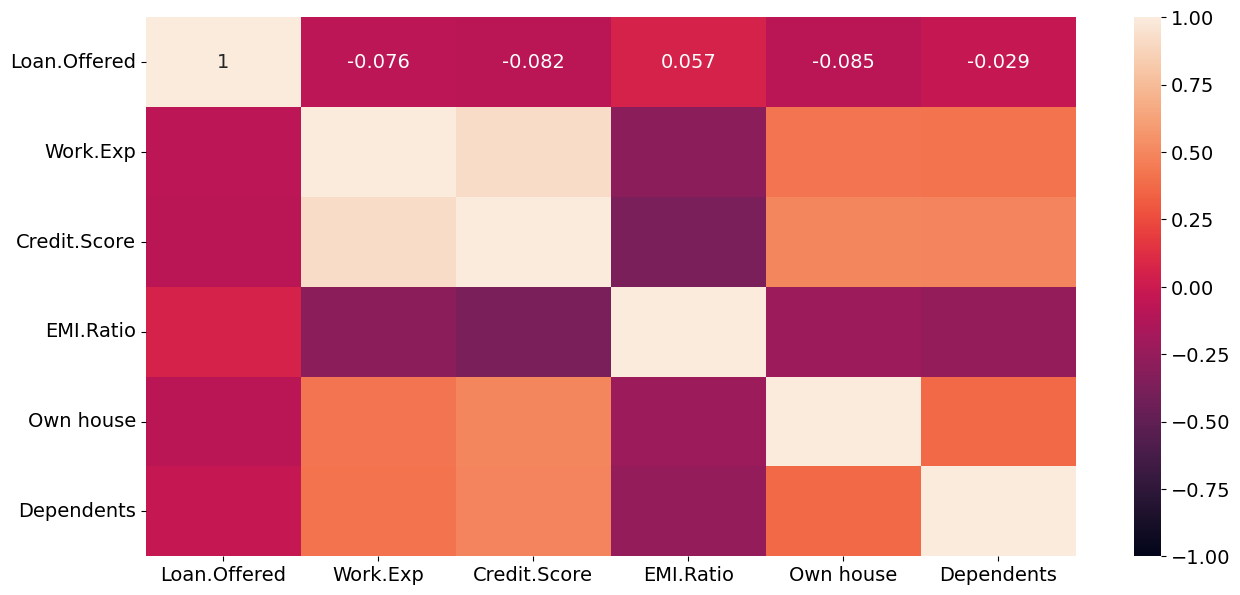

In [10]:
plt.figure(figsize=(15,7))
num_col = data.select_dtypes(include='number')
sns.heatmap(num_col.corr(), vmin=-1, vmax=1, annot=True)
plt.show();

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to 

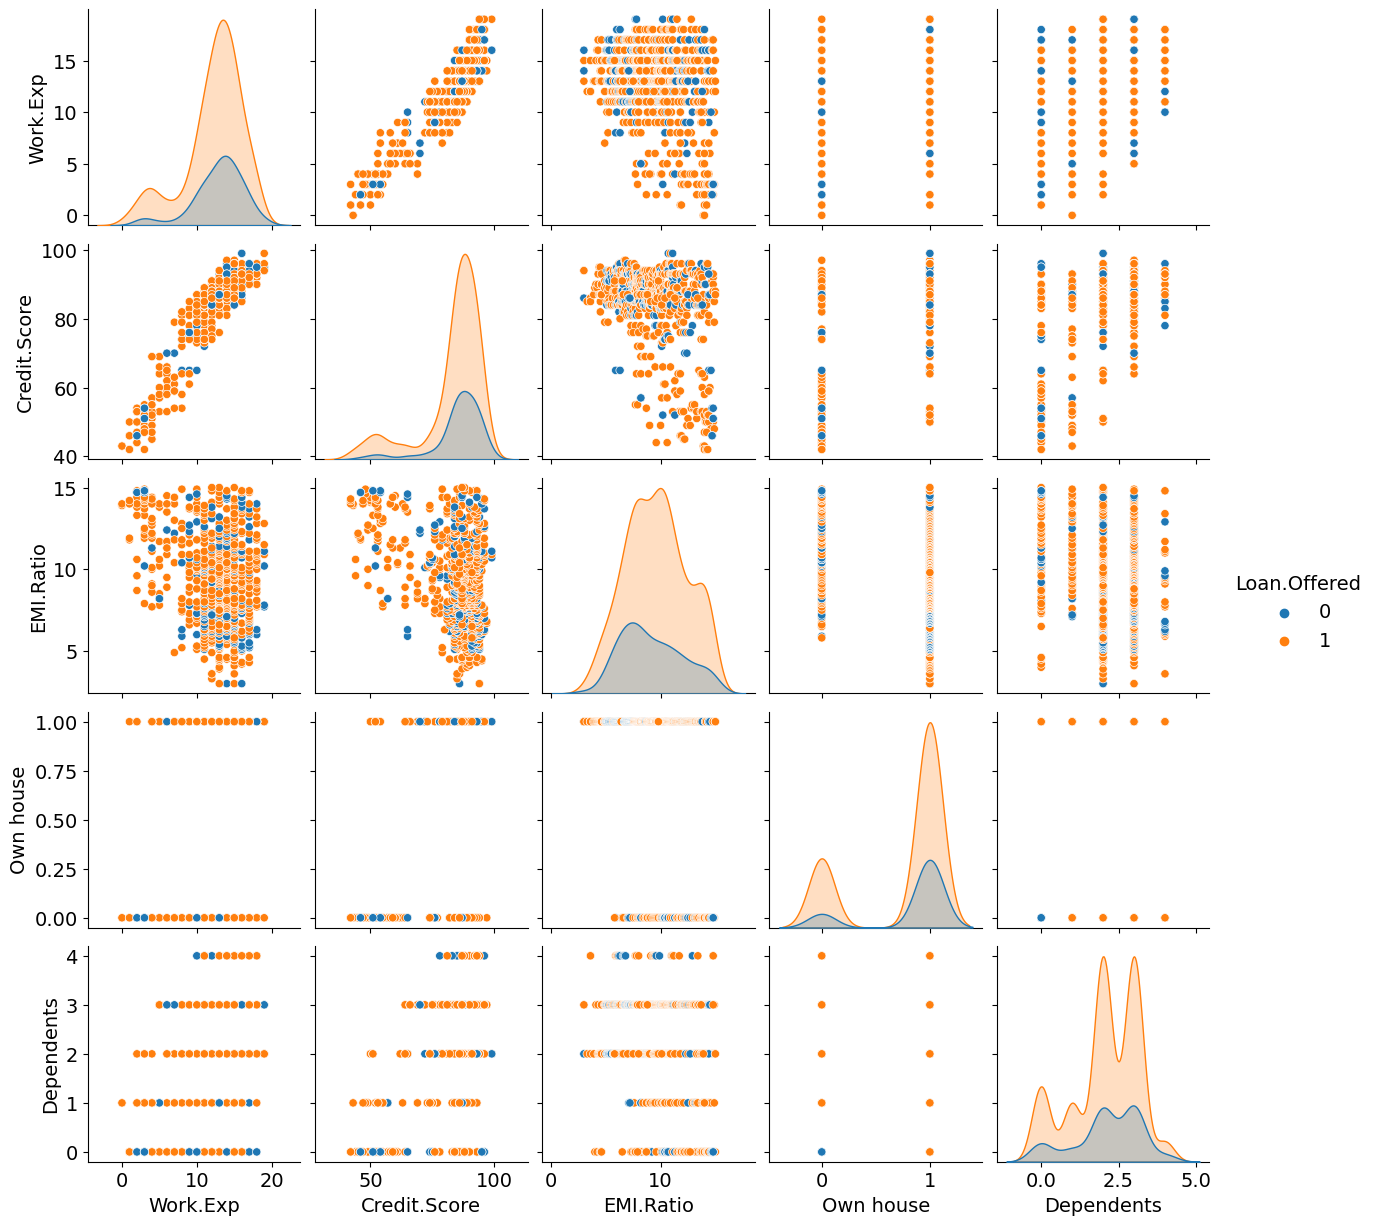

In [11]:
sns.pairplot(data, hue='Loan.Offered')
plt.show();

In [12]:
data['Loan.Offered'].value_counts(1).round(2)*100

Loan.Offered
1    76.0
0    24.0
Name: proportion, dtype: float64

In [13]:
x = data.drop(['Loan.Offered'], axis=1)
y = data['Loan.Offered']
x = add_constant(x)
x = pd.get_dummies(x, drop_first=True).astype(int)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, stratify = y, random_state = 1)

In [14]:
lg = sm.Logit(y_train, x_train).fit()

         Current function value: 0.276383
         Iterations: 35


C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [15]:
pred_train = np.round(lg.predict(x_train)>0.5)

In [16]:
accuracy_score(y_train, pred_train)

0.8905982905982905

In [17]:
cm = confusion_matrix(y_train, pred_train)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,439,4
Actual Negative,60,82


In [18]:
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:           Loan.Offered   No. Observations:                  585
Model:                          Logit   Df Residuals:                      567
Method:                           MLE   Df Model:                           17
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                  0.5013
Time:                        07:47:52   Log-Likelihood:                -161.68
converged:                      False   LL-Null:                       -324.21
Covariance Type:            nonrobust   LLR p-value:                 7.402e-59
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       31.0697   2.56e+05      0.000      1.000   -5.01e+05    5.01e+05
Work.Exp                    -0.0713      0.101     -0.709      0.478      -0.268       0.

In [19]:
vif_series = pd.Series([variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])],
                       index = x_train.columns,
                       dtype = float)
vif_series

const                       322.750656
Work.Exp                      7.476752
Credit.Score                  9.950762
EMI.Ratio                     2.580897
Own house                     3.090753
Dependents                    3.049575
Gender_Male                   1.811032
Job_skilled                   2.243857
Job_unskilled                 1.932216
Status_No                     4.897113
Credit.History_critical      11.323170
Credit.History_good          18.925764
Credit.History_poor           7.261939
Credit.History_very good     24.244525
Credit.History_verygood       7.880770
Purpose_consumer.durable      5.049163
Purpose_education             7.553371
Purpose_personal              8.141400
dtype: float64

In [20]:
x_train1 = x_train.drop(columns=['Job_unskilled',
                                 'Status_No',
                                 'Credit.History_critical',
                                 'Credit.History_good',
                                 'Credit.History_poor',
                                 'Credit.History_very good',
                                 'Credit.History_verygood'],axis=1)

In [21]:
lg1 = sm.Logit(y_train, x_train1).fit()
pred_train1 = np.round(lg1.predict(x_train1))

Optimization terminated successfully.
         Current function value: 0.384426
         Iterations 7


In [22]:
print(lg1.summary())

                           Logit Regression Results                           
Dep. Variable:           Loan.Offered   No. Observations:                  585
Model:                          Logit   Df Residuals:                      574
Method:                           MLE   Df Model:                           10
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                  0.3064
Time:                        07:47:52   Log-Likelihood:                -224.89
converged:                       True   LL-Null:                       -324.21
Covariance Type:            nonrobust   LLR p-value:                 3.087e-37
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.9606      1.841      0.522      0.602      -2.649       4.570
Work.Exp                    -0.1868      0.086     -2.162      0.031      -0.356      -0.

In [23]:
x_train2 = x_train1.drop(columns=['Credit.Score',
                                  'Purpose_consumer.durable',
                                  'Purpose_education',
                                  'Purpose_personal'], axis=1)

In [24]:
lg2 = sm.Logit(y_train, x_train2).fit()

Optimization terminated successfully.
         Current function value: 0.385894
         Iterations 7


In [25]:
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:           Loan.Offered   No. Observations:                  585
Model:                          Logit   Df Residuals:                      578
Method:                           MLE   Df Model:                            6
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                  0.3037
Time:                        07:47:52   Log-Likelihood:                -225.75
converged:                       True   LL-Null:                       -324.21
Covariance Type:            nonrobust   LLR p-value:                 8.532e-40
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.9294      0.812      1.144      0.253      -0.663       2.521
Work.Exp       -0.2087      0.042     -4.912      0.000      -0.292      -0.125
EMI.Ratio      -0.1017      0.048     -2.132    

In [26]:
pred_train2 = np.round(lg2.predict(x_train2))

In [27]:
cm = confusion_matrix(y_train, pred_train2)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,408,35
Actual Negative,63,79


In [28]:
accuracy_score(y_train, pred_train2)

0.8324786324786325

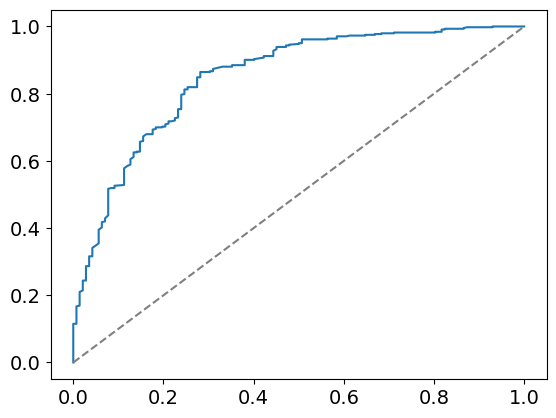

In [29]:
fpr,tpr,_ = roc_curve(y_train, lg2.predict(x_train2))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--',color='grey')
plt.show();

### Final Model Predictions

In [30]:
x_test = x_test.drop(columns=['Job_unskilled',
                              'Status_No',
                              'Credit.History_critical',
                              'Credit.History_good',
                              'Credit.History_poor',
                              'Credit.History_very good',
                              'Credit.History_verygood',
                              'Credit.Score',
                              'Purpose_consumer.durable',
                              'Purpose_education',
                              'Purpose_personal'], axis=1)

In [31]:
pred_test = np.round(lg2.predict(x_test))

In [32]:
accuracy_score(y_test, pred_test)

0.8418367346938775

In [33]:
cm = confusion_matrix(y_test, pred_test)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,136,12
Actual Negative,19,29


### Gaussian NB

In [34]:
df.head()

,Gender,Loan.Offered,Job,Work.Exp,Credit.Score,EMI.Ratio,Status,Credit.History,Own house,Purpose,Dependents
0,Male,0,unskilled,14,86,3.0,No,poor,1,personal,2
1,Female,1,skilled,15,94,3.0,No,poor,1,personal,3
2,Male,0,unskilled,16,86,3.0,No,poor,1,personal,2
3,Female,1,skilled,13,94,3.0,No,poor,1,personal,3
4,Male,1,skilled,12,85,3.3,No,poor,1,personal,2


In [35]:
x_nb = df.drop(['Loan.Offered'], axis=1)
y_nb = df['Loan.Offered']
x_nb = pd.get_dummies(x_nb, drop_first = True)
x_train, x_test, y_train, y_test = train_test_split(x_nb, y_nb, test_size = 0.3, stratify = y, random_state = 1)

In [36]:
model = GaussianNB()
model.fit(x_train, y_train.ravel())

GaussianNB()

In [37]:
pred_train = model.predict(x_train)

In [39]:
print(classification_report(y_train, pred_train))

              precision    recall  f1-score   support

           0       0.99      0.56      0.72       133
           1       0.88      1.00      0.93       413

    accuracy                           0.89       546
   macro avg       0.93      0.78      0.83       546
weighted avg       0.90      0.89      0.88       546



In [40]:
cm = confusion_matrix(y_train, pred_train)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,412,1
Actual Negative,58,75


### Prediction on test set

In [41]:
pred_test = model.predict(x_test)

In [43]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       1.00      0.53      0.69        57
           1       0.87      1.00      0.93       178

    accuracy                           0.89       235
   macro avg       0.93      0.76      0.81       235
weighted avg       0.90      0.89      0.87       235



In [44]:
cm = confusion_matrix(y_test, pred_test)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                         [cm[0,1],cm[0,0]]],
                         columns = ['Predicted Positive','Predicted Negative'],
                         index = ['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,178,0
Actual Negative,27,30
